Testing the Differences between using **Continuous** vs **Discrete** Mnist Images

The Model was trained using continuous Mnist Dataset

##### Dependencies

In [1]:
import os
import sys

# Get the current file's directory and move up one directory
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))

# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
# used to train the DiffLogic models with different configs taken from config.yaml
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
import random
import mnist_dataset
import torchvision.transforms as transforms
from tqdm import tqdm 

# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Classes

In [2]:
class DiffLogic(nn.Module):
    def __init__(self, layers_config, output_size, tau=30):
        """
        Initializes the DiffLogic model with the specified layer configurations, output size, and temperature parameter.

        Args:
            layers_config (dict): Configuration for each logic layer, including dimensions, device, implementation, connections, and grad factor.
            output_size (int): The number of output groups.
            tau (int): Temperature parameter for the GroupSum operation.
        """
        super(DiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        for layer_name, config in layers_config.items():
            layer = LogicLayer(
                in_dim=config['in_dim'],
                out_dim=config['out_dim'],
                device=config['device'],
                implementation=config['implementation'],
                connections=config['connections'],
                grad_factor=config['grad_factor']       
            )
            layers.append(layer)
            print(layer)
        
        self.logic_layers = nn.Sequential(*layers)
        
        self.group = GroupSum(k=output_size, tau=tau)
    
    def forward(self, x):
        """
        Forward pass of the DiffLogic model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after processing through the logic layers and grouping operation.
        """
        # Move tensor to GPU
        if torch.cuda.is_available():
            x = x.to('cuda')          
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group
    
class Model(nn.Module):
    def __init__(self, cfg):
        """
        Initializes the Model, loads the DiffLogic model, sets up the optimizer, loss function, and other necessary configurations.

        Args:
            cfg (dict): Configuration dictionary containing model parameters such as layer configurations, output size, tau, and learning rate.
        """
        super(Model, self).__init__()
        
        layers_config = cfg["layers_config"]
        output_size = cfg["output_size"]
        tau = cfg["tau"]
                
        self.diff_logic_model = DiffLogic(layers_config, output_size=output_size, tau=tau)
        self.optimizer = torch.optim.Adam(self.diff_logic_model.parameters(), lr=cfg["learning_rate"])
        self.log_text = ""  # Initialize the logging string
        self.data_batch = []
        self.criterion = nn.CrossEntropyLoss() # loss function for classification tasks

    def forward(self, prediction_dict):    
        """
        Forward pass to predict the model output.

        Args:
            prediction_dict (dict): Dictionary containing input data for making predictions.

        Returns:
            None: Updates the prediction_dict with the predicted output data.
        """
        input_data = prediction_dict["input_data"]
        output = self.diff_logic_model(input_data)
        self.log_text += f"State Prediction: {output}\n"
        prediction_dict["pred_output_data"] = output

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.

        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.

        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction, label)

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.

        Returns:
            None
        """
        self.optimizer.step()

    def train(self, tdata, mem, batch_size):
        """
        Training method that returns the loss after receiving a batch of data.

        Args:
            tdata (any): Training data.
            mem (any): Memory buffer or additional data needed for training.
            batch_size (int): Size of the data batch for training.

        Returns:
            torch.Tensor: The loss value for the batch.
        """
        self.optimizer.zero_grad()
        loss = torch.tensor([0.0 for i in range(batch_size)])
        return loss

    def test_train(self, prediction_dict):
        """
        Training method for system development on a dummy dataset.

        Args:
            prediction_dict (dict): Dictionary containing predicted and true output data.

        Returns:
            torch.Tensor: The computed loss.
        """
        self.optimizer.zero_grad()
        loss = self.loss(prediction_dict["pred_output_data"], prediction_dict["true_output_data"]).flatten()  # Structure loss (DNN relies on down-stream prediction)  
        return loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.

        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model

        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.diff_logic_model.logic_layers if isinstance(layer, LogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))
        self.log_text += f"Model saved to: {file_path}\n"

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.

        Args:
            file_path (str): Path from which the model will be loaded.

        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.diff_logic_model.eval()
        self.log_text += f"Model loaded from: {file_path}\n"

    def plot_loss(self, loss_history):
        """
        Plots the training loss over epochs.

        Args:
            loss_history (list): List containing the loss values for each epoch.

        Returns:
            None
        """
        plt.figure()
        plt.plot(loss_history, label='Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Epochs')
        plt.legend()
        plt.show()
        self.log_text += "Loss plot generated\n"

    def visualize_model(self):
        """
        Generates a visualization of the model using a dummy input.

        Returns:
            None
        """
        dummy_input = torch.randn(1, cfg["input_dim"])  # Adjust this as needed based on your input dimensions
        y = self.diff_logic_model(dummy_input)
        g = make_dot(y, params=dict(self.diff_logic_model.named_parameters()))
        g.view()
        self.log_text += "Model visualization generated\n"

    def get_log(self):
        """
        Retrieves the log text and clears the log after retrieval.

        Returns:
            str: The log text.
        """
        log_copy = self.log_text
        self.log_text = ""  # Clear the log after returning
        return log_copy

    def explain(self):
        """
        Placeholder function for explaining the model's decisions.

        Returns:
            None
        """
        return None
    
    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader
        
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader
            
        Returns:
            float: The accuracy
        """
        correct = 0
        total = 0
    
        # Ensure model is in evaluation mode
        self.diff_logic_model.eval()

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

                # Forward pass to get predictions
                outputs = self.diff_logic_model(batch_inputs)

                # Get the predicted class (index of the maximum logit)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += batch_outputs.size(0)  # Total number of samples in the batch
                correct += (predicted == batch_outputs).sum().item()  # Count correct predictions

        accuracy = correct / total
        return accuracy
    
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        """
        Initializes the EarlyStopper to stop training if the performance doesn't improve after a certain number of epochs.

        Args:
            patience (int): Number of epochs to wait for an improvement.
            min_delta (float): Minimum change to consider an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def should_stop(self, current_loss):
        """
        Check if training should stop based on the current loss.

        Args:
            current_loss (float): The current loss.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if self.best_loss is None:
            self.best_loss = current_loss
            return False
        elif current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print("EarlyStopper Triggered: ", self.counter)
            if self.counter >= self.patience:
                return True
            return False

### Binary Mnist

##### Dataset

In [3]:
small_mnist = True
binarize_images = True  
evenly_partitioned = True
batch_size = 256

# function to binarize an image
def binarize(image, threshold=0.5):
    return (image > threshold).float()  # Threshold the image to convert to binary (0 or 1)

# define the transformation logic based on the toggle
if binarize_images:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: binarize(x))  # apply binarization if enabled
    ])
else:
    transform = transforms.Compose([
        transforms.ToTensor()  # just convert to tensor if not binarizing
    ])
    
train_dataset = mnist_dataset.MNIST('../data-mnist', train=True, remove_border=small_mnist, transform=transform)
test_dataset = mnist_dataset.MNIST('../data-mnist', train=False, remove_border=small_mnist, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True, )
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

In [4]:
# Make Dataset Evenly Partitioned
if evenly_partitioned:
    # code below is used so that all classes have the same number of samples
    train_targets = train_loader.dataset.targets
    test_targets = test_loader.dataset.targets

    train_digits_total = []
    test_digits_total = []

    for i in range(10):
        curr_tot_train = torch.sum(train_targets == i).item()
        curr_tot_test = torch.sum(test_targets == i).item()    
        train_digits_total.append(curr_tot_train)
        test_digits_total.append(curr_tot_test)

    train_digits_total, test_digits_total

    # find the minimum number of samples across all classes
    min_samples_train = min(train_digits_total)
    min_samples_test = min(test_digits_total)

    # function to trim dataset to match the minimum samples for each class and shuffle indices
    def trim_dataset(dataset, targets, min_samples):
        indices = []
        for i in range(10):
            class_indices = (targets == i).nonzero(as_tuple=True)[0]  # get indices of class i
            class_indices = class_indices[:min_samples]  # trim to min_samples
            indices.extend(class_indices)

        # shuffle indices after collecting them
        indices = torch.tensor(indices)
        indices = indices[torch.randperm(indices.size(0))]  

        return Subset(dataset, indices)

    # trim both train and test datasets to ensure all classes have the same number of samples
    trimmed_train_dataset = trim_dataset(train_loader.dataset, train_targets, min_samples_train)
    trimmed_test_dataset = trim_dataset(test_loader.dataset, test_targets, min_samples_test)

    # create DataLoaders for the trimmed datasets
    trimmed_train_loader = DataLoader(trimmed_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    trimmed_test_loader = DataLoader(trimmed_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

    # verify the lengths of the trimmed datasets
    len(trimmed_train_loader.dataset), len(trimmed_test_loader.dataset)

    train_dataset = trimmed_train_dataset
    test_dataset = trimmed_test_dataset
    train_loader = trimmed_train_loader
    test_loader = trimmed_test_loader

In [5]:
sample_size = len(train_loader.dataset) + len(test_loader.dataset)
len(train_loader.dataset), len(test_loader.dataset)

(54210, 8920)

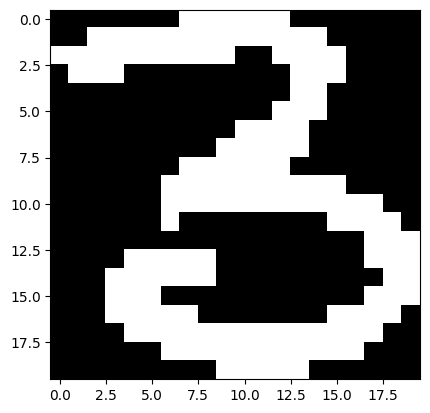

In [6]:
# visualizes random image 
dataset_size = len(train_dataset)
random_index = random.randint(0, dataset_size - 1)

if small_mnist:
    image = train_loader.dataset[random_index][0].reshape(20, 20)
else:
    image = train_loader.dataset[random_index][0].reshape(28, 28)
plt.imshow(image, cmap='gray')

#### Inference

In [7]:
# this uses a model trained on a binarized mnist dataset
model_name = 'model_077'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_binary_models'
PATH = f'../{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="../config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
print(model)

model.get_accuracy(test_loader)

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Model(
  (diff_logic_model): DiffLogic(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (logic_layers): Sequential(
      (0): LogicLayer(400, 2500, eval)
      (1): LogicLayer(2500, 2500, eval)
    )
    (group): GroupSum(k=10, tau=10)
  )
  (criterion): CrossEntropyLoss()
)


Running Inference: 100%|██████████| 34/34 [00:06<00:00,  5.02it/s]


0.9237132352941176

#### Switching Probability

In [8]:
# ALL_OPERATIONS is used to map the argmax value of the weights to the corresponding logic gate
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

# dictionary with the logic probability of each gate under the assumption both gate inputs A and B == 1
ALL_OPERATIONS_PROBS = {
    "zero": 0.00, "and": 0.25, "not_implies": 0.25, "a": 0.50, "not_implied_by": 0.25,
    "b": 0.50, "xor": 0.50, "or": 0.75, "not_or": 0.25, "not_xor": 0.50,
    "not_b": 0.50, "implied_by": 0.75, "not_a": 0.50, "implies": 0.75,
    "not_and": 0.75, "one": 1.00
}

def get_gate_switching_probs(model, data_loader):
    """
    Tracks the learned logic gate (based on weights) and the switching probability for each neuron.

    Args:
        model: The trained DiffLogic model.
        data_loader: DataLoader with the dataset to evaluate (e.g., test_loader).

    Returns:
        gate_prob_dict_per_layer: A list of dictionaries, each containing the learned gate and switching probability for neurons in a layer.
    """
    activation_counts_per_layer = []
    gates_per_layer = []
    gates_initialized = [] 
    hooks = []

    # hook function to track activations and logic gates for each neuron
    def hook_fn(module, input, output, layer_idx):
        # initializes activation counts and gates for the layer if not done already
        if len(activation_counts_per_layer) <= layer_idx:
            activation_counts_per_layer.append(np.zeros(output.size(1)))
            gates_per_layer.append([])
            gates_initialized.append(False)  # Mark that gates are not initialized yet for this layer

        # store activations (output > 0 means it fired) 
        # *this has the same effect as using output == 1 if working with binarized images
        activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

        # only stores learned logic gates if they haven't been recorded yet
        if not gates_initialized[layer_idx]:
            for neuron_idx in range(output.size(1)):
                # gets the learned gate by taking the argmax of the weights for the neuron
                gate_op_idx = module.weights[neuron_idx].argmax().item()
                learned_gate = ALL_OPERATIONS[gate_op_idx]

                # gets the input connections (indices) for the gate
                input_neuron_a = module.indices[0][neuron_idx].item()
                input_neuron_b = module.indices[1][neuron_idx].item()

                gates_per_layer[layer_idx].append({
                    'Gate': learned_gate,
                    'Inputs': (input_neuron_a, input_neuron_b),
                    'a': input_neuron_a, 
                    'b': input_neuron_b,
                })

            # mark that gates have been initialized for this layer
            gates_initialized[layer_idx] = True

    # register hooks on all LogicLayers and track the layer index
    for idx, layer in enumerate(model.diff_logic_model.logic_layers):
        if isinstance(layer, LogicLayer):
            hook = layer.register_forward_hook(lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx))
            hooks.append(hook)

    # sets model to eval mode and  track total number of images processed
    model.diff_logic_model.eval()  
    total_images = 0 

    # disable gradient computation and runs forward pass
    with torch.no_grad():  
        for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
            batch_inputs = batch_inputs.to('cuda')
            model.diff_logic_model(batch_inputs)  
            total_images += batch_inputs.size(0)

    # calculates switching probabilities and create dictionaries of gate + switching prob for each layer
    gate_prob_dict_per_layer = []
    for layer_idx in range(len(activation_counts_per_layer)):
        layer_probs = activation_counts_per_layer[layer_idx] / total_images

        # Debugging: Check if lengths match before proceeding
        num_gates = len(gates_per_layer[layer_idx])
        num_activations = len(layer_probs)

        print(f"Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")

        if num_gates != num_activations:
            print(f"Warning: Mismatch in Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")
            continue  # Skip this layer if there is a mismatch
    
        gate_prob_dict = {}
        
        # Loop through the gates in this layer and calculate the necessary values
        for i in range(num_gates):
            learned_gate = gates_per_layer[layer_idx][i]['Gate']
            actual_prob = layer_probs[i]
            predicted_prob = ALL_OPERATIONS_PROBS[learned_gate]
            
            # Calculate prob_a and prob_b based on the formula
            new_value = actual_prob * (1 - predicted_prob) / 2
            prob_a, prob_b = new_value, new_value  

            gate_prob_dict[f"Gate {i+1}"] = {
                "Learned Gate": learned_gate,
                "Inputs": gates_per_layer[layer_idx][i]['Inputs'],
                "Observed Switching Probability": actual_prob, # switching frequency
                "Expected Switching Probability": predicted_prob, # logic probability, e.g. P('AND') = 0.25
                "a": gates_per_layer[layer_idx][i]['a'],                  
                "prob_a": prob_a,
                "b": gates_per_layer[layer_idx][i]['b'], 
                "prob_b": prob_b,
            }
        
        gate_prob_dict_per_layer.append(gate_prob_dict)

    # remove hooks to clean up
    for hook in hooks:
        hook.remove()

    return gate_prob_dict_per_layer

# Use the model = get_gate_switching_probs(model, test_loader)
gate_switching_probs = get_gate_switching_probs(model, test_loader)

Processing MNIST images: 100%|██████████| 34/34 [00:02<00:00, 16.43it/s]

Layer 1 - Gates: 2500, Activations: 2500
Layer 2 - Gates: 2500, Activations: 2500


In [9]:
def get_average_switching_probs_first_layer(gate_switching_probs, num_pixels=400):
    """
    Calculates the average switching probability for each specific pixel (node) from the first layer in gate_switching_probs.
    
    Args:
        gate_switching_probs: List of dictionaries containing switching probabilities and inputs for each gate.
        num_pixels: The total number of nodes/pixels (default is 400 for a 20x20 image).
    
    Returns:
        avg_switching_probs: A list containing the average switching probability for each node.
    """
    # Initialize a dictionary to store the total switching probability and count for each pixel
    pixel_switching_data = {pixel: {"total_prob": 0, "count": 0} for pixel in range(num_pixels)}

    # Process only the first layer (gate_switching_probs[0])
    first_layer = gate_switching_probs[0]

    # For each gate in the first layer, get the inputs (a and b) and their corresponding switching probabilities
    for gate, data in first_layer.items():
        a = data['a']  # First input node
        b = data['b']  # Second input node
        prob_a = data['prob_a']  # Switching probability for input a
        prob_b = data['prob_b']  # Switching probability for input b

        # Accumulate the switching probabilities for pixel 'a' if within bounds
        if 0 <= a < num_pixels:
            pixel_switching_data[a]['total_prob'] += prob_a
            pixel_switching_data[a]['count'] += 1
        else:
            print(f"Warning: Node 'a' with index {a} is out of bounds.")

        # Accumulate the switching probabilities for pixel 'b' if within bounds
        if 0 <= b < num_pixels:
            pixel_switching_data[b]['total_prob'] += prob_b
            pixel_switching_data[b]['count'] += 1
        else:
            print(f"Warning: Node 'b' with index {b} is out of bounds.")

    # Calculate the average switching probability for each pixel
    avg_switching_probs = []
    for pixel in range(num_pixels):
        total_prob = pixel_switching_data[pixel]['total_prob']
        count = pixel_switching_data[pixel]['count']
        # Avoid division by zero; if no activations, average is zero
        avg_prob = total_prob / count if count > 0 else 0
        avg_switching_probs.append(avg_prob)

    return avg_switching_probs

In [19]:
if small_mnist:
    num_pixels=400
else:
    num_pixels=784

average_switching_probs_first_layer = get_average_switching_probs_first_layer(gate_switching_probs, num_pixels)

#max(average_switching_probs_first_layer)

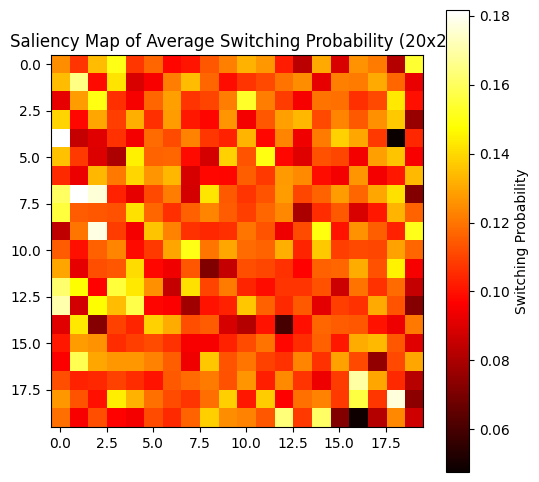

In [20]:
# Assume `average_switching_probs_first_layer` contains the 400 average switching probabilities for the first layer
saliency_map = np.reshape(average_switching_probs_first_layer, (20, 20))

# Plotting the saliency map
plt.figure(figsize=(6, 6))
plt.imshow(saliency_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Switching Probability')
plt.title('Saliency Map of Average Switching Probability (20x20)')
plt.show()

In [196]:
# check using 28x28 if edges are less important -- sanity check

In [10]:
switching_probs = []
for i in range(len(gate_switching_probs)):
    switching_probs.append([gate['Observed Switching Probability'] for gate in gate_switching_probs[i].values()])

##### Switching Probability Visualizations

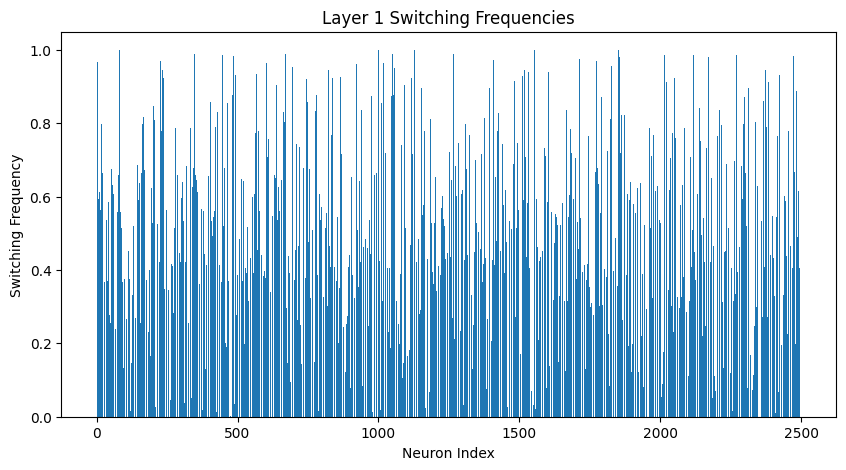

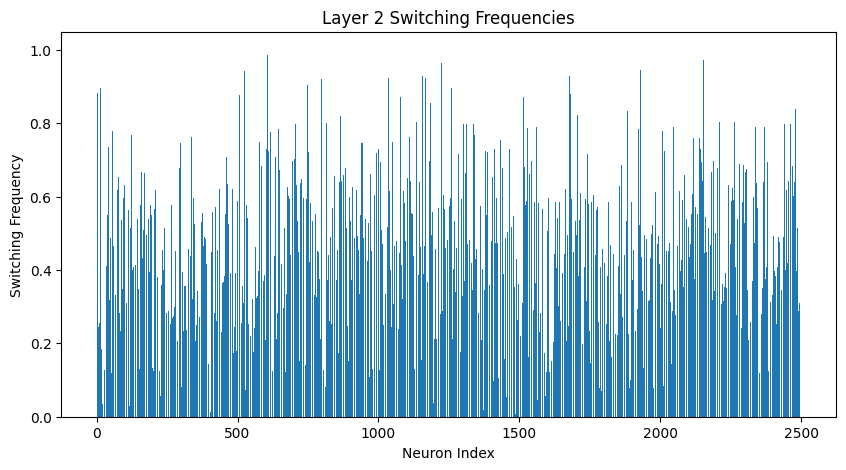

In [11]:
def visualize_switching_probabilities(switching_probs):
    """
    Plots switching probabilities across layers as a bar chart or heatmap.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(probs)), probs)
        plt.title(f"Layer {idx + 1} Switching Frequencies")
        plt.xlabel("Neuron Index")
        plt.ylabel("Switching Frequency")
        plt.show()

visualize_switching_probabilities(switching_probs)

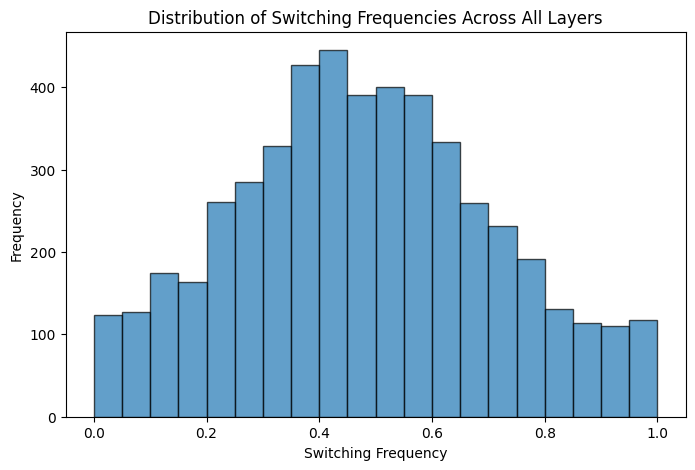

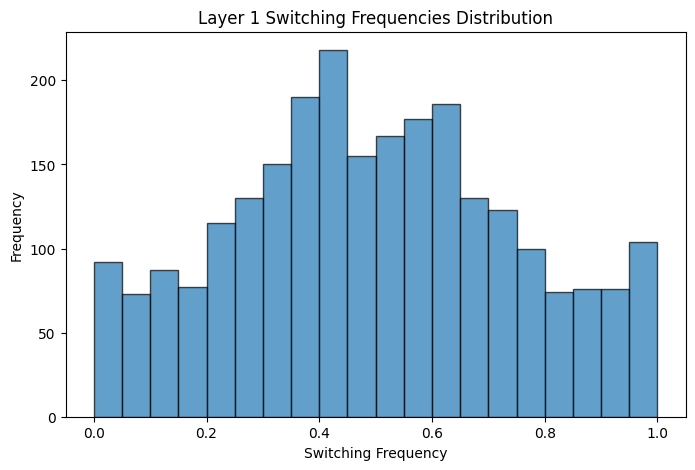

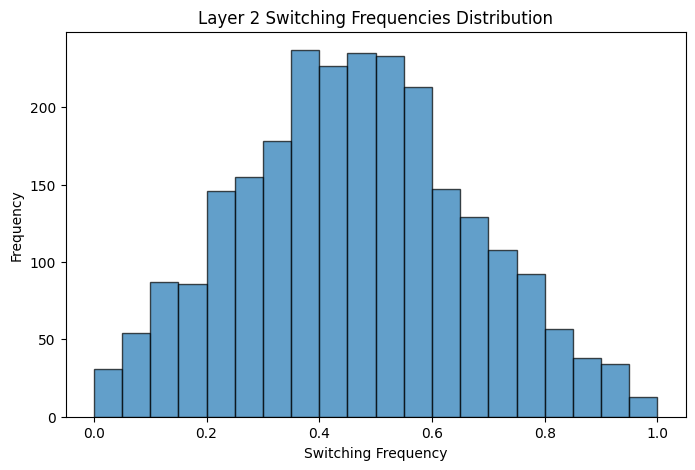

In [12]:
import matplotlib.pyplot as plt

def visualize_switching_probabilities(switching_probs):
    """
    Plots the distribution of switching probabilities across layers using histograms.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    # Flatten all switching probabilities into a single list to plot the overall distribution
    all_probs = [prob for layer_probs in switching_probs for prob in layer_probs]

    # Plot the distribution of switching probabilities for all layers
    plt.figure(figsize=(8, 5))
    plt.hist(all_probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    plt.title("Distribution of Switching Frequencies Across All Layers")
    plt.xlabel("Switching Frequency")
    plt.ylabel("Frequency")
    plt.show()

    # Plot histograms for each layer
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Layer {idx + 1} Switching Frequencies Distribution")
        plt.xlabel("Switching Frequency")
        plt.ylabel("Frequency")
        plt.show()

# Example usage
visualize_switching_probabilities(switching_probs)

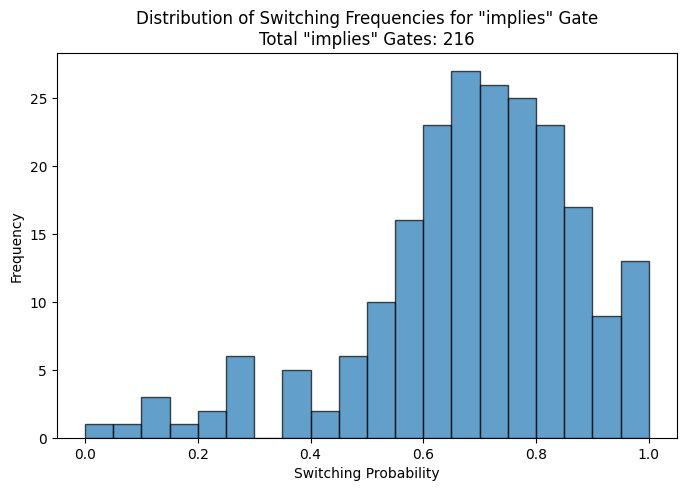

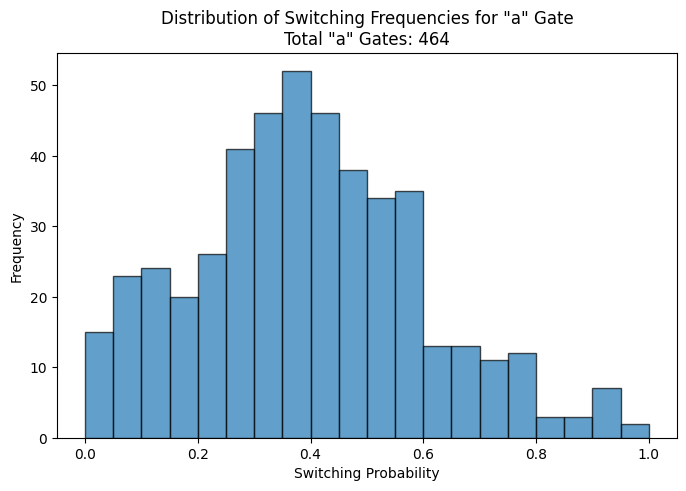

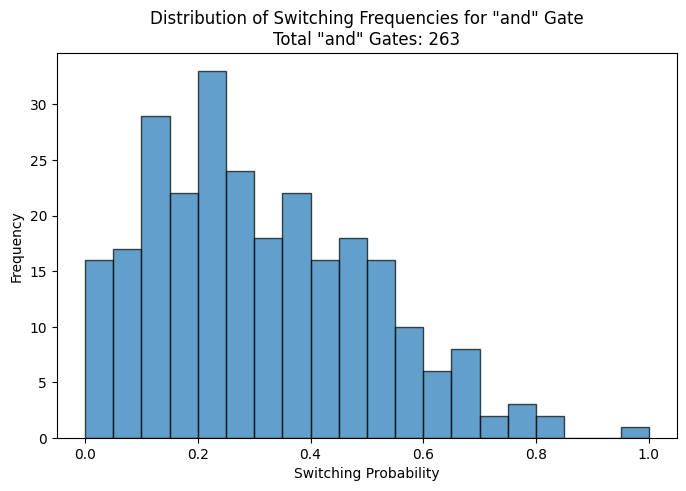

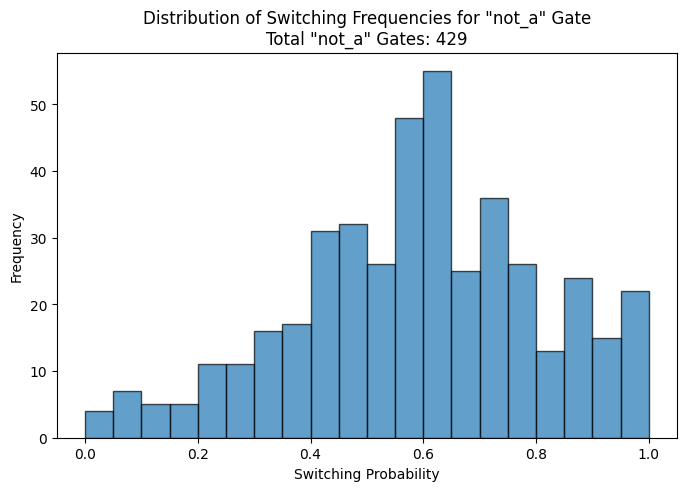

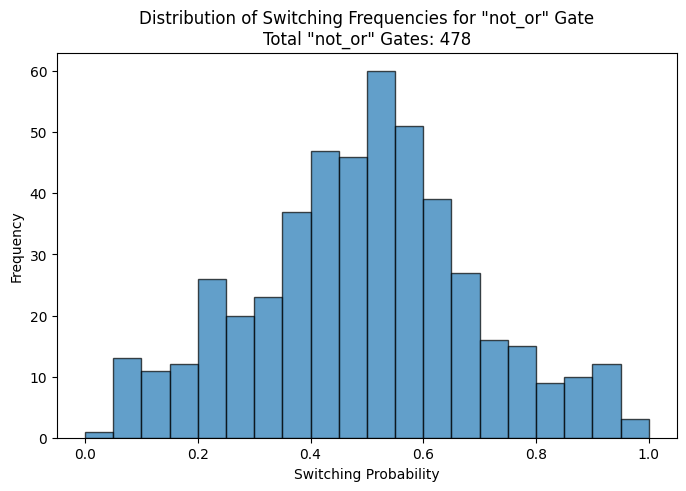

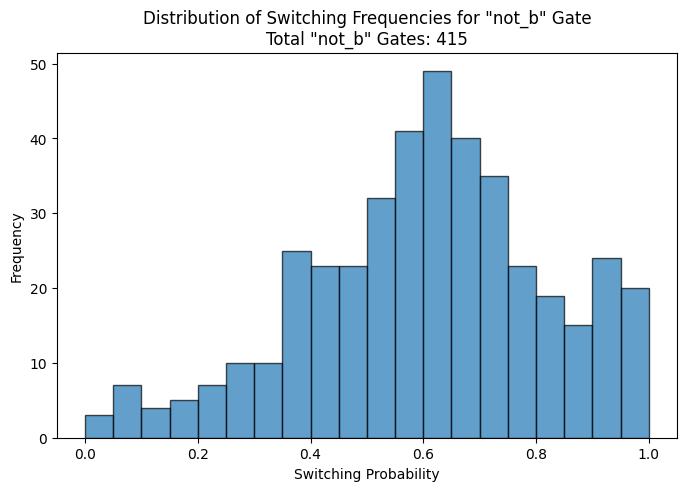

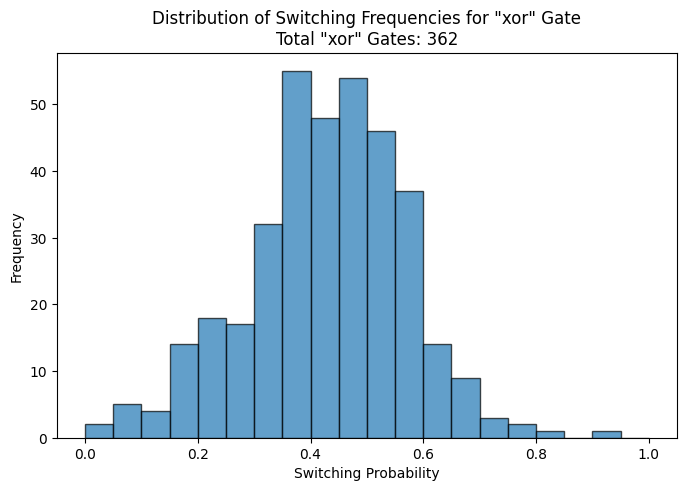

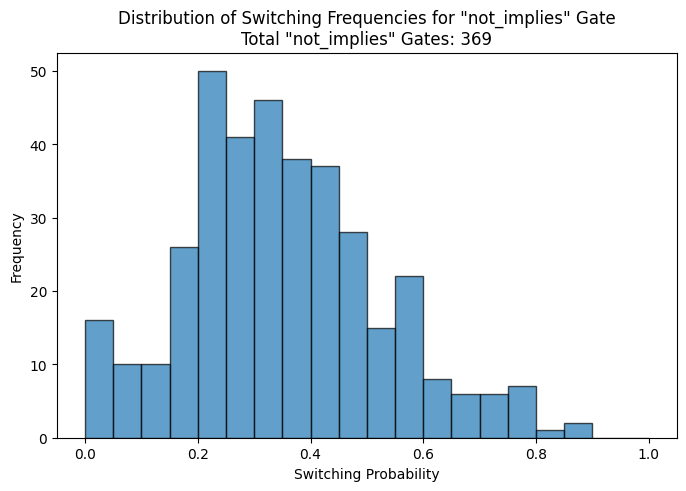

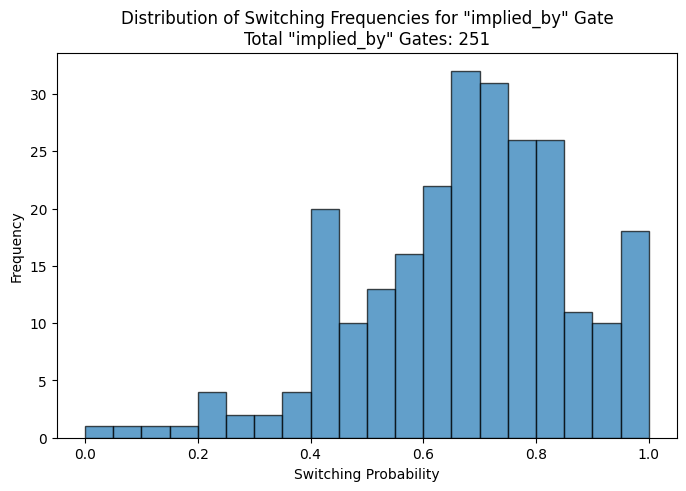

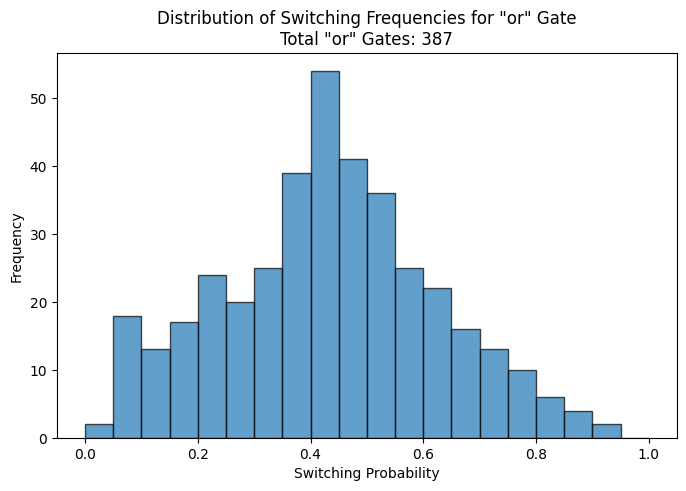

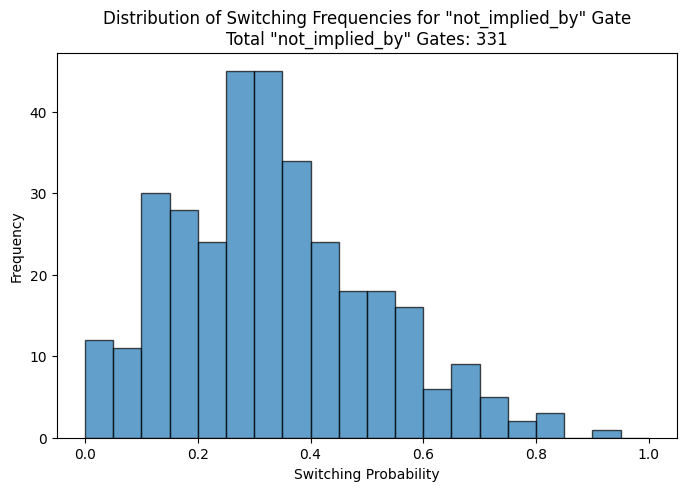

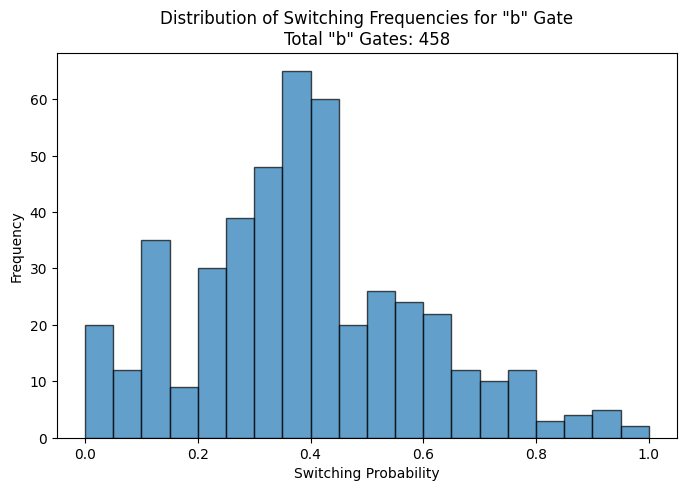

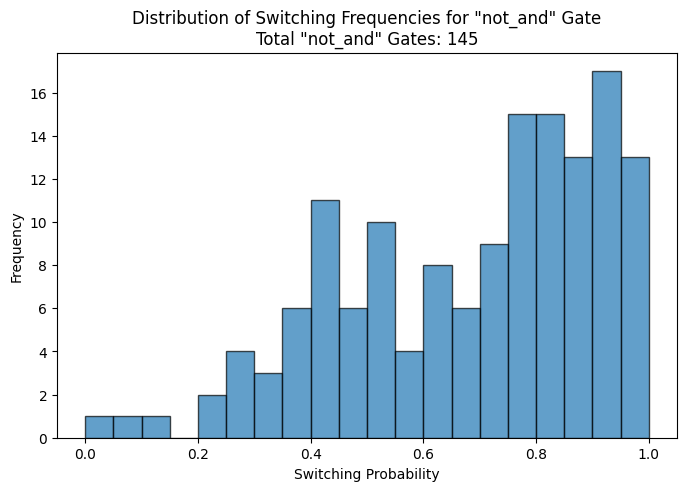

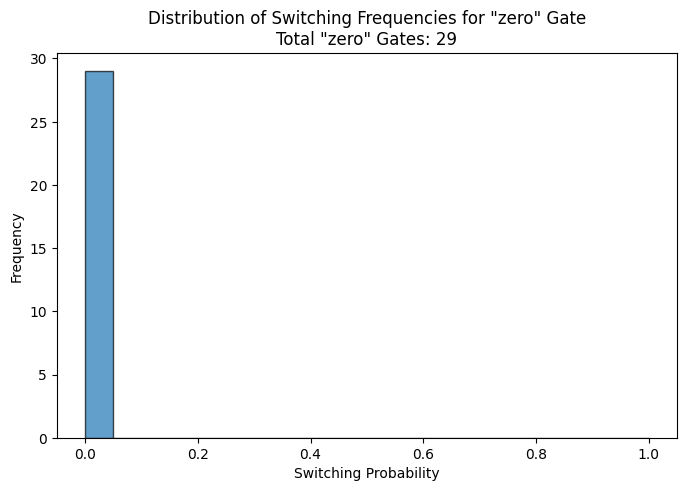

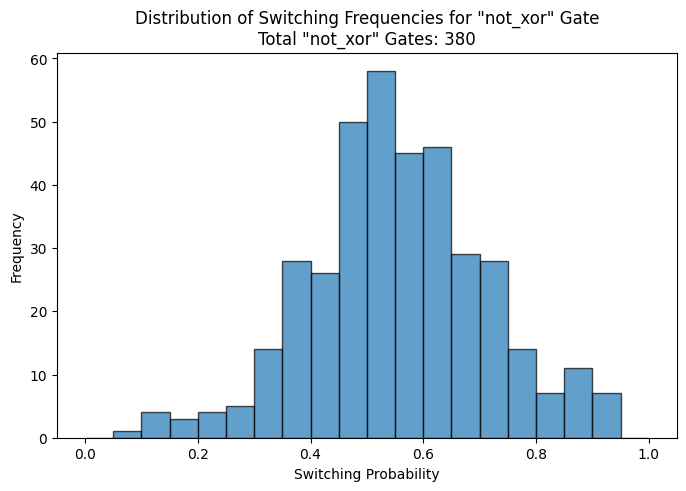

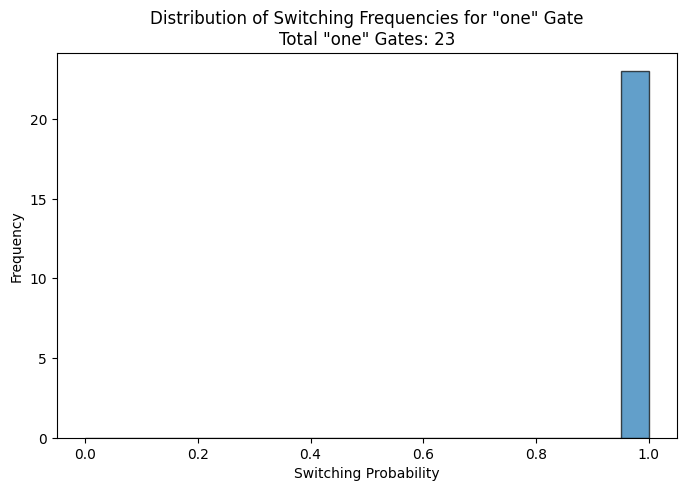

Total "implies" Gates: 216
Total "a" Gates: 464
Total "and" Gates: 263
Total "not_a" Gates: 429
Total "not_or" Gates: 478
Total "not_b" Gates: 415
Total "xor" Gates: 362
Total "not_implies" Gates: 369
Total "implied_by" Gates: 251
Total "or" Gates: 387
Total "not_implied_by" Gates: 331
Total "b" Gates: 458
Total "not_and" Gates: 145
Total "zero" Gates: 29
Total "not_xor" Gates: 380
Total "one" Gates: 23


In [13]:
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_switching_probabilities_by_gate(gate_prob_dict_per_layer):
    """
    Plots the distribution of switching probabilities for each learned gate across layers using histograms.
    
    Args:
        gate_prob_dict_per_layer: A list of dictionaries per layer, each containing the learned gate and its switching probability for neurons in that layer.
    """
    # Dictionary to hold switching probabilities grouped by gate type
    gate_switching_probs = defaultdict(list)
    
    # Dictionary to track the total count of each gate type
    gate_counts = defaultdict(int)

    # Collect switching probabilities and count gates for each gate type across layers
    for layer_dict in gate_prob_dict_per_layer:
        for gate_key, gate_data in layer_dict.items():
            gate_type = gate_data['Learned Gate']  # The gate type (e.g., AND, OR, etc.)
            switching_prob = gate_data['Observed Switching Probability']  # The switching probability for this neuron

            # Append the switching probability to the corresponding gate type
            gate_switching_probs[gate_type].append(switching_prob)
            gate_counts[gate_type] += 1  # Increment the gate count for this gate type

    # Plot the distribution of switching probabilities for each gate type
    for gate_type, probs in gate_switching_probs.items():
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Distribution of Switching Frequencies for \"{gate_type}\" Gate\nTotal \"{gate_type}\" Gates: {gate_counts[gate_type]}")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

    # Print out the total gate counts for each gate type
    for gate_type, count in gate_counts.items():
        print(f"Total \"{gate_type}\" Gates: {count}")

# Example usage with the output of your get_gate_switching_probs function
visualize_switching_probabilities_by_gate(gate_switching_probs)

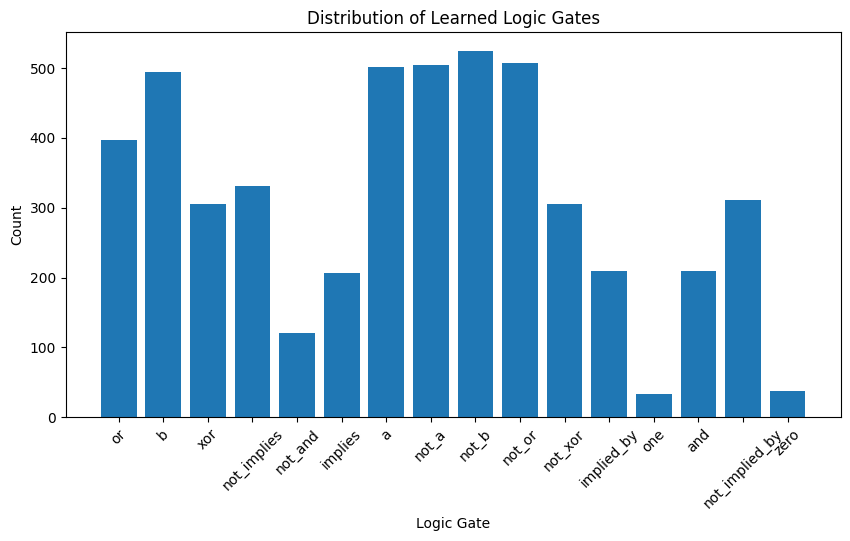

In [39]:
def get_high_activity_neurons(gate_switching_probs, threshold=0.5):
    """
    Finds neurons with switching probability greater than a threshold, and their associated logic gates.
    
    Args:
        gate_switching_probs: Output from get_gate_switching_probs.
        threshold: Switching probability threshold to consider a neuron as high-activity.

    Returns:
        high_activity_neurons: A dictionary with layer, neuron index, learned gate, inputs, and switching probability.
    """
    high_activity_neurons = []

    for layer_idx, gates in enumerate(gate_switching_probs):
        for neuron_idx, gate_info in gates.items():
            if gate_info["Observed Switching Probability"] >= threshold:
                high_activity_neurons.append({
                    "Layer": layer_idx + 1,
                    "Neuron": neuron_idx,
                    "Gate": gate_info["Learned Gate"],
                    "Inputs": gate_info["Inputs"],
                    "Switching Probability": gate_info["Observed Switching Probability"]
                })
    
    return high_activity_neurons

high_activity_neurons = get_high_activity_neurons(gate_switching_probs, threshold=0)
# print(high_activity_neurons)

from collections import Counter

def visualize_gate_distribution(high_activity_neurons):
    """
    Plots a bar chart showing the distribution of learned logic gates for high-activity neurons.
    
    Args:
        high_activity_neurons: Output from get_high_activity_neurons.
    """
    # Count gate occurrences
    gate_counter = Counter([neuron["Gate"] for neuron in high_activity_neurons])
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(gate_counter.keys(), gate_counter.values())
    plt.title("Distribution of Learned Logic Gates")
    plt.xlabel("Logic Gate")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Example usage:
visualize_gate_distribution(high_activity_neurons)

### Continuous Mnist

##### Dataset

In [42]:
small_mnist = True
binarize_images = False  
evenly_partitioned = True
batch_size = 256

# function to binarize an image
def binarize(image, threshold=0.5):
    return (image > threshold).float()  # Threshold the image to convert to binary (0 or 1)

# define the transformation logic based on the toggle
if binarize_images:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: binarize(x))  # apply binarization if enabled
    ])
else:
    transform = transforms.Compose([
        transforms.ToTensor()  # just convert to tensor if not binarizing
    ])
    
train_dataset = mnist_dataset.MNIST('../data-mnist', train=True, remove_border=small_mnist, transform=transform)
test_dataset = mnist_dataset.MNIST('../data-mnist', train=False, remove_border=small_mnist, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True, )
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

In [43]:
# Make Dataset Evenly Partitioned
if evenly_partitioned:
    # code below is used so that all classes have the same number of samples
    train_targets = train_loader.dataset.targets
    test_targets = test_loader.dataset.targets

    train_digits_total = []
    test_digits_total = []

    for i in range(10):
        curr_tot_train = torch.sum(train_targets == i).item()
        curr_tot_test = torch.sum(test_targets == i).item()    
        train_digits_total.append(curr_tot_train)
        test_digits_total.append(curr_tot_test)

    train_digits_total, test_digits_total

    # find the minimum number of samples across all classes
    min_samples_train = min(train_digits_total)
    min_samples_test = min(test_digits_total)

    # function to trim dataset to match the minimum samples for each class and shuffle indices
    def trim_dataset(dataset, targets, min_samples):
        indices = []
        for i in range(10):
            class_indices = (targets == i).nonzero(as_tuple=True)[0]  # get indices of class i
            class_indices = class_indices[:min_samples]  # trim to min_samples
            indices.extend(class_indices)

        # shuffle indices after collecting them
        indices = torch.tensor(indices)
        indices = indices[torch.randperm(indices.size(0))]  

        return Subset(dataset, indices)

    # trim both train and test datasets to ensure all classes have the same number of samples
    trimmed_train_dataset = trim_dataset(train_loader.dataset, train_targets, min_samples_train)
    trimmed_test_dataset = trim_dataset(test_loader.dataset, test_targets, min_samples_test)

    # create DataLoaders for the trimmed datasets
    trimmed_train_loader = DataLoader(trimmed_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    trimmed_test_loader = DataLoader(trimmed_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

    # verify the lengths of the trimmed datasets
    len(trimmed_train_loader.dataset), len(trimmed_test_loader.dataset)

    train_dataset = trimmed_train_dataset
    test_dataset = trimmed_test_dataset
    train_loader = trimmed_train_loader
    test_loader = trimmed_test_loader

In [44]:
sample_size = len(train_loader.dataset) + len(test_loader.dataset)
len(train_loader.dataset), len(test_loader.dataset)

(54210, 8920)

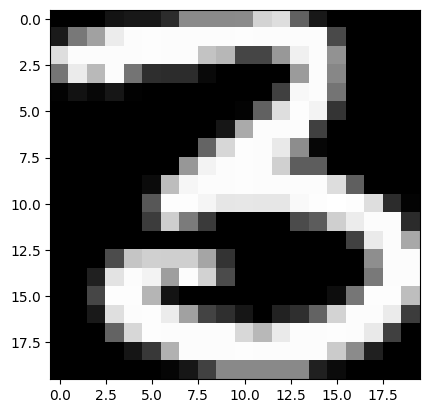

In [45]:
# visualizes random image 
dataset_size = len(train_dataset)
random_index = random.randint(0, dataset_size - 1)

if small_mnist:
    image = train_loader.dataset[random_index][0].reshape(20, 20)
else:
    image = train_loader.dataset[random_index][0].reshape(28, 28)
plt.imshow(image, cmap='gray')

#### Inference

In [46]:
model_name = 'model_077'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models'
PATH = f'../{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="../config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
print(model)

model.get_accuracy(test_loader)

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Model(
  (diff_logic_model): DiffLogic(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (logic_layers): Sequential(
      (0): LogicLayer(400, 2500, eval)
      (1): LogicLayer(2500, 2500, eval)
    )
    (group): GroupSum(k=10, tau=10)
  )
  (criterion): CrossEntropyLoss()
)


Running Inference: 100%|██████████| 34/34 [00:01<00:00, 21.88it/s]


0.9134880514705882

#### Switching Probability

In [47]:
# ALL_OPERATIONS is used to map the argmax value of the weights to the corresponding logic gate
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

# dictionary with the logic probability of each gate under the assumption both gate inputs A and B == 1
ALL_OPERATIONS_PROBS = {
    "zero": 0.00, "and": 0.25, "not_implies": 0.25, "a": 0.50, "not_implied_by": 0.25,
    "b": 0.50, "xor": 0.50, "or": 0.75, "not_or": 0.25, "not_xor": 0.50,
    "not_b": 0.50, "implied_by": 0.75, "not_a": 0.50, "implies": 0.75,
    "not_and": 0.75, "one": 1.00
}

def get_gate_switching_probs(model, data_loader):
    """
    Tracks the learned logic gate (based on weights) and the switching probability for each neuron.

    Args:
        model: The trained DiffLogic model.
        data_loader: DataLoader with the dataset to evaluate (e.g., test_loader).

    Returns:
        gate_prob_dict_per_layer: A list of dictionaries, each containing the learned gate and switching probability for neurons in a layer.
    """
    activation_counts_per_layer = []
    gates_per_layer = []
    gates_initialized = [] 
    hooks = []

    # hook function to track activations and logic gates for each neuron
    def hook_fn(module, input, output, layer_idx):
        # initializes activation counts and gates for the layer if not done already
        if len(activation_counts_per_layer) <= layer_idx:
            activation_counts_per_layer.append(np.zeros(output.size(1)))
            gates_per_layer.append([])
            gates_initialized.append(False)  # Mark that gates are not initialized yet for this layer

        # store activations (output > 0 means it fired) 
        # *this has the same effect as using output == 1 if working with binarized images
        activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

        # only stores learned logic gates if they haven't been recorded yet
        if not gates_initialized[layer_idx]:
            for neuron_idx in range(output.size(1)):
                # gets the learned gate by taking the argmax of the weights for the neuron
                gate_op_idx = module.weights[neuron_idx].argmax().item()
                learned_gate = ALL_OPERATIONS[gate_op_idx]

                # gets the input connections (indices) for the gate
                input_neuron_a = module.indices[0][neuron_idx].item()
                input_neuron_b = module.indices[1][neuron_idx].item()

                gates_per_layer[layer_idx].append({
                    'Gate': learned_gate,
                    'Inputs': (input_neuron_a, input_neuron_b),
                    'a': input_neuron_a, 
                    'b': input_neuron_b,
                })

            # mark that gates have been initialized for this layer
            gates_initialized[layer_idx] = True

    # register hooks on all LogicLayers and track the layer index
    for idx, layer in enumerate(model.diff_logic_model.logic_layers):
        if isinstance(layer, LogicLayer):
            hook = layer.register_forward_hook(lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx))
            hooks.append(hook)

    # sets model to eval mode and  track total number of images processed
    model.diff_logic_model.eval()  
    total_images = 0 

    # disable gradient computation and runs forward pass
    with torch.no_grad():  
        for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
            batch_inputs = batch_inputs.to('cuda')
            model.diff_logic_model(batch_inputs)  
            total_images += batch_inputs.size(0)

    # calculates switching probabilities and create dictionaries of gate + switching prob for each layer
    gate_prob_dict_per_layer = []
    for layer_idx in range(len(activation_counts_per_layer)):
        layer_probs = activation_counts_per_layer[layer_idx] / total_images

        # Debugging: Check if lengths match before proceeding
        num_gates = len(gates_per_layer[layer_idx])
        num_activations = len(layer_probs)

        print(f"Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")

        if num_gates != num_activations:
            print(f"Warning: Mismatch in Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")
            continue  # Skip this layer if there is a mismatch
    
        gate_prob_dict = {}
        
        # Loop through the gates in this layer and calculate the necessary values
        for i in range(num_gates):
            learned_gate = gates_per_layer[layer_idx][i]['Gate']
            actual_prob = layer_probs[i]
            predicted_prob = ALL_OPERATIONS_PROBS[learned_gate]
            
            # Calculate prob_a and prob_b based on the formula
            new_value = actual_prob * (1 - predicted_prob) / 2
            prob_a, prob_b = new_value, new_value  

            gate_prob_dict[f"Gate {i+1}"] = {
                "Learned Gate": learned_gate,
                "Inputs": gates_per_layer[layer_idx][i]['Inputs'],
                "Observed Switching Probability": actual_prob, # switching frequency
                "Expected Switching Probability": predicted_prob, # logic probability, e.g. P('AND') = 0.25
                "a": gates_per_layer[layer_idx][i]['a'],                  
                "prob_a": prob_a,
                "b": gates_per_layer[layer_idx][i]['b'], 
                "prob_b": prob_b,
            }
        
        gate_prob_dict_per_layer.append(gate_prob_dict)

    # remove hooks to clean up
    for hook in hooks:
        hook.remove()

    return gate_prob_dict_per_layer

# Use the model = get_gate_switching_probs(model, test_loader)
gate_switching_probs = get_gate_switching_probs(model, test_loader)

Processing MNIST images: 100%|██████████| 34/34 [00:01<00:00, 19.17it/s]

Layer 1 - Gates: 2500, Activations: 2500
Layer 2 - Gates: 2500, Activations: 2500


In [48]:
def get_average_switching_probs_first_layer(gate_switching_probs, num_pixels=400):
    """
    Calculates the average switching probability for each specific pixel (node) from the first layer in gate_switching_probs.
    
    Args:
        gate_switching_probs: List of dictionaries containing switching probabilities and inputs for each gate.
        num_pixels: The total number of nodes/pixels (default is 400 for a 20x20 image).
    
    Returns:
        avg_switching_probs: A list containing the average switching probability for each node.
    """
    # Initialize a dictionary to store the total switching probability and count for each pixel
    pixel_switching_data = {pixel: {"total_prob": 0, "count": 0} for pixel in range(num_pixels)}

    # Process only the first layer (gate_switching_probs[0])
    first_layer = gate_switching_probs[0]

    # For each gate in the first layer, get the inputs (a and b) and their corresponding switching probabilities
    for gate, data in first_layer.items():
        a = data['a']  # First input node
        b = data['b']  # Second input node
        prob_a = data['prob_a']  # Switching probability for input a
        prob_b = data['prob_b']  # Switching probability for input b

        # Accumulate the switching probabilities for pixel 'a' if within bounds
        if 0 <= a < num_pixels:
            pixel_switching_data[a]['total_prob'] += prob_a
            pixel_switching_data[a]['count'] += 1
        else:
            print(f"Warning: Node 'a' with index {a} is out of bounds.")

        # Accumulate the switching probabilities for pixel 'b' if within bounds
        if 0 <= b < num_pixels:
            pixel_switching_data[b]['total_prob'] += prob_b
            pixel_switching_data[b]['count'] += 1
        else:
            print(f"Warning: Node 'b' with index {b} is out of bounds.")

    # Calculate the average switching probability for each pixel
    avg_switching_probs = []
    for pixel in range(num_pixels):
        total_prob = pixel_switching_data[pixel]['total_prob']
        count = pixel_switching_data[pixel]['count']
        # Avoid division by zero; if no activations, average is zero
        avg_prob = total_prob / count if count > 0 else 0
        avg_switching_probs.append(avg_prob)

    return avg_switching_probs

In [49]:
if small_mnist:
    num_pixels=400
else:
    num_pixels=784

average_switching_probs_first_layer = get_average_switching_probs_first_layer(gate_switching_probs, num_pixels)

#max(average_switching_probs_first_layer)

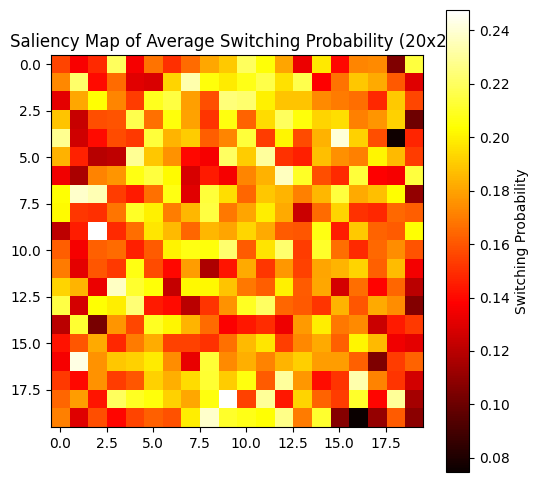

In [50]:
# Assume `average_switching_probs_first_layer` contains the 400 average switching probabilities for the first layer
saliency_map = np.reshape(average_switching_probs_first_layer, (20, 20))

# Plotting the saliency map
plt.figure(figsize=(6, 6))
plt.imshow(saliency_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Switching Probability')
plt.title('Saliency Map of Average Switching Probability (20x20)')
plt.show()

In [196]:
# check using 28x28 if edges are less important -- sanity check

In [51]:
switching_probs = []
for i in range(len(gate_switching_probs)):
    switching_probs.append([gate['Observed Switching Probability'] for gate in gate_switching_probs[i].values()])

##### Switching Probability Visualizations

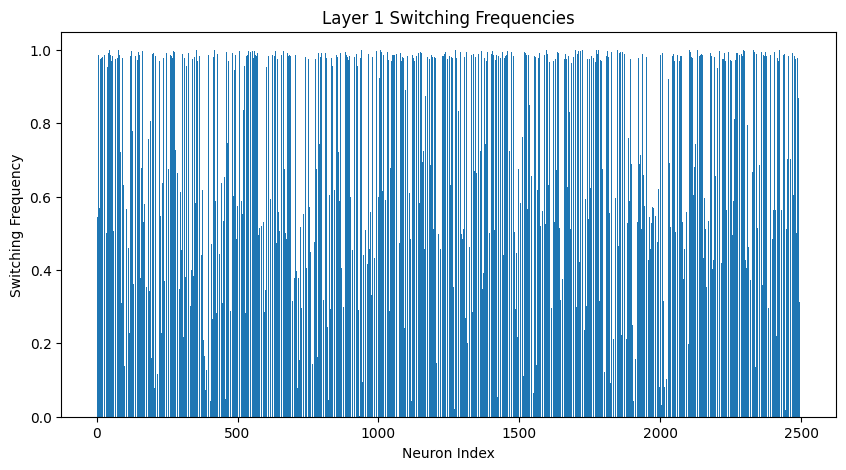

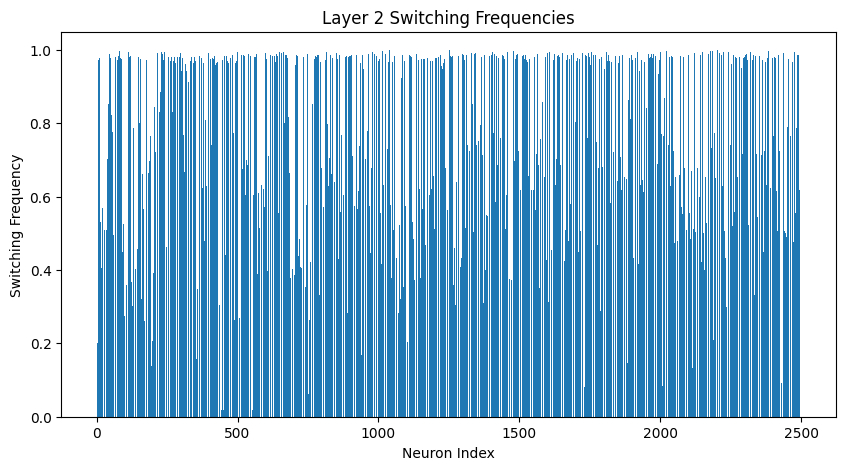

In [52]:
def visualize_switching_probabilities(switching_probs):
    """
    Plots switching probabilities across layers as a bar chart or heatmap.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(probs)), probs)
        plt.title(f"Layer {idx + 1} Switching Frequencies")
        plt.xlabel("Neuron Index")
        plt.ylabel("Switching Frequency")
        plt.show()

visualize_switching_probabilities(switching_probs)

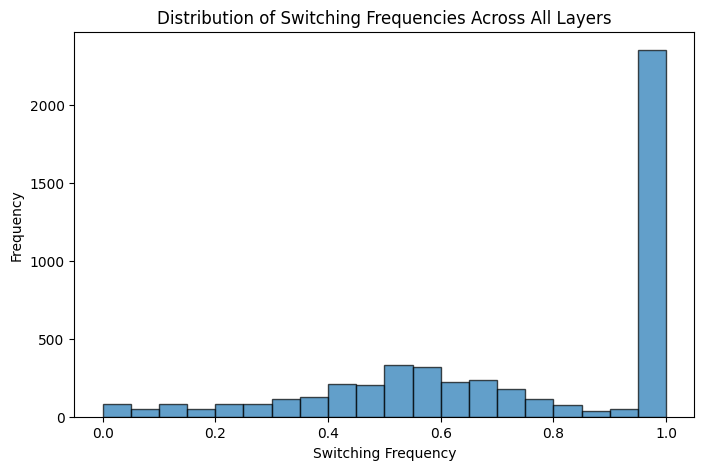

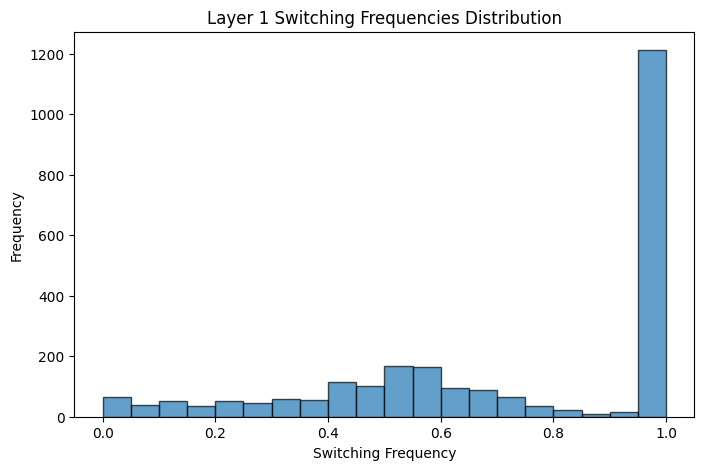

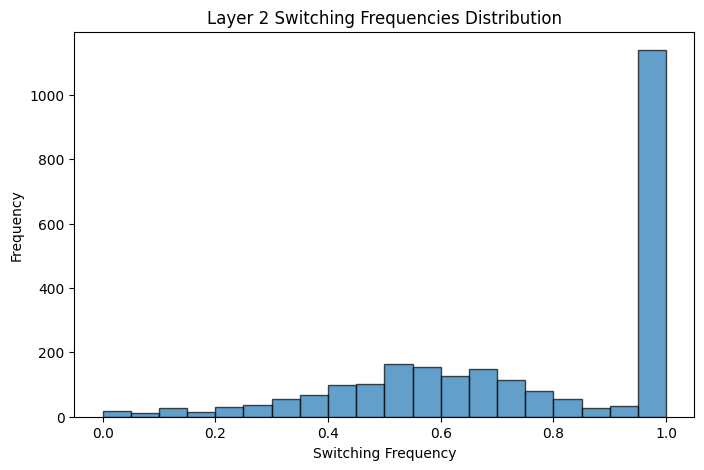

In [53]:
import matplotlib.pyplot as plt

def visualize_switching_probabilities(switching_probs):
    """
    Plots the distribution of switching probabilities across layers using histograms.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    # Flatten all switching probabilities into a single list to plot the overall distribution
    all_probs = [prob for layer_probs in switching_probs for prob in layer_probs]

    # Plot the distribution of switching probabilities for all layers
    plt.figure(figsize=(8, 5))
    plt.hist(all_probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    plt.title("Distribution of Switching Frequencies Across All Layers")
    plt.xlabel("Switching Frequency")
    plt.ylabel("Frequency")
    plt.show()

    # Plot histograms for each layer
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Layer {idx + 1} Switching Frequencies Distribution")
        plt.xlabel("Switching Frequency")
        plt.ylabel("Frequency")
        plt.show()

# Example usage
visualize_switching_probabilities(switching_probs)

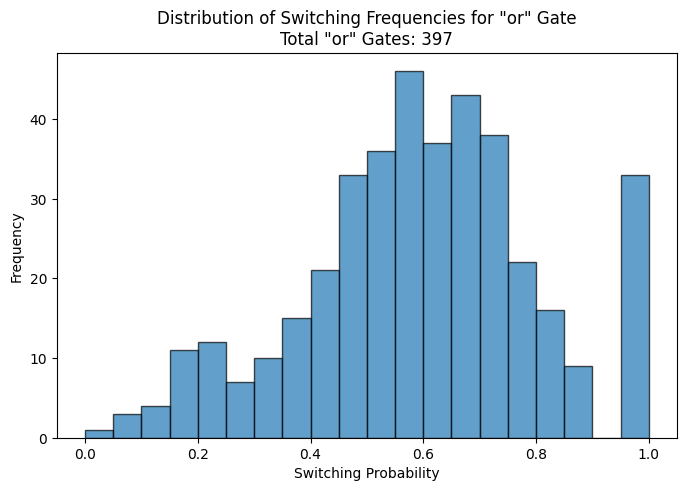

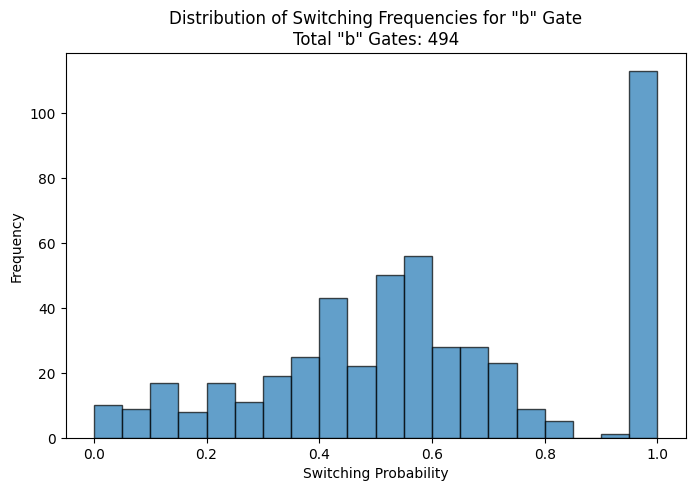

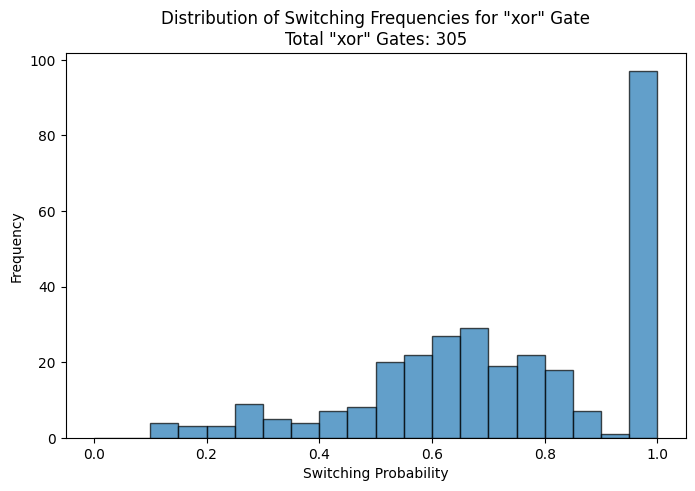

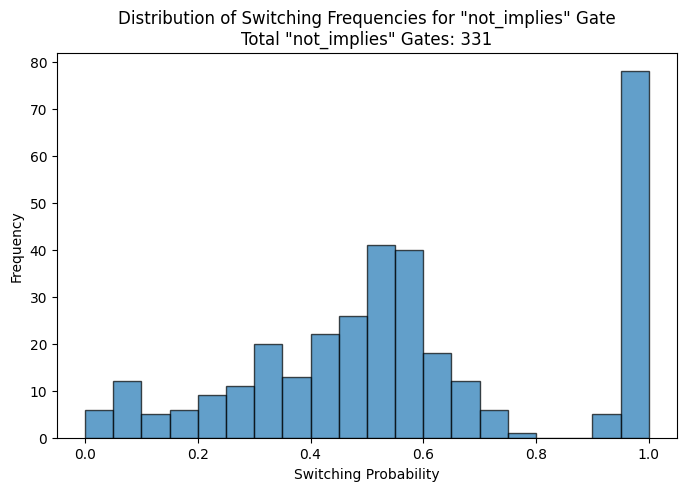

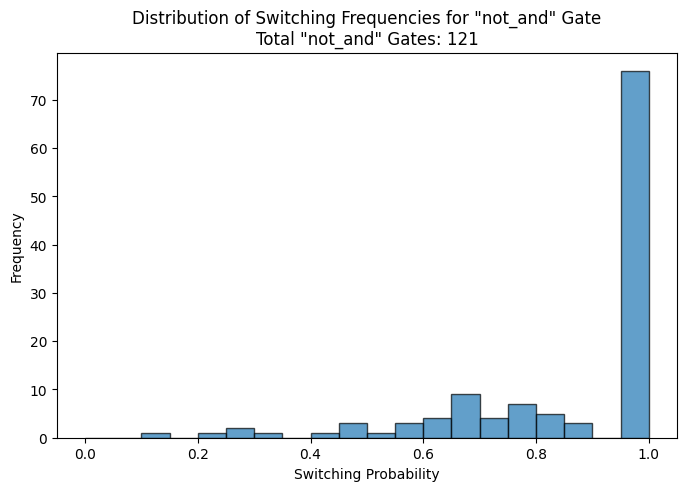

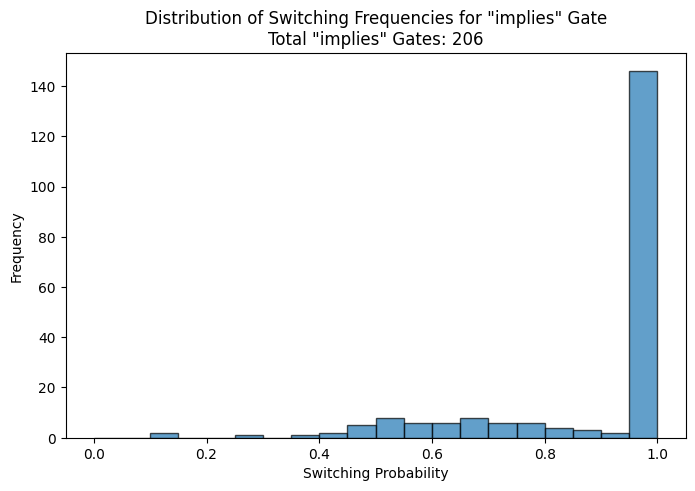

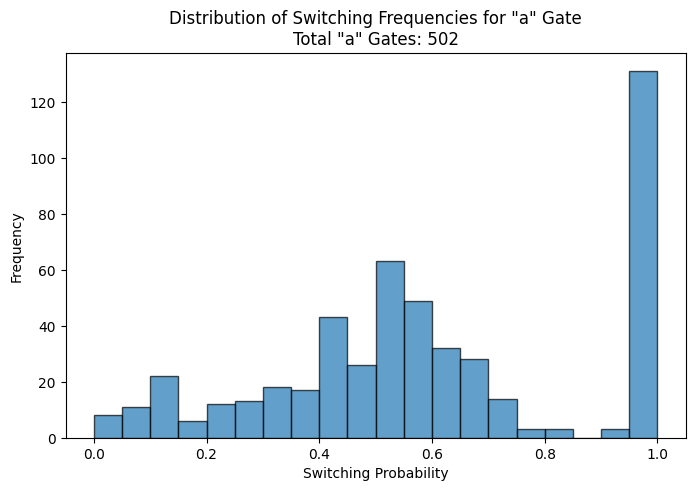

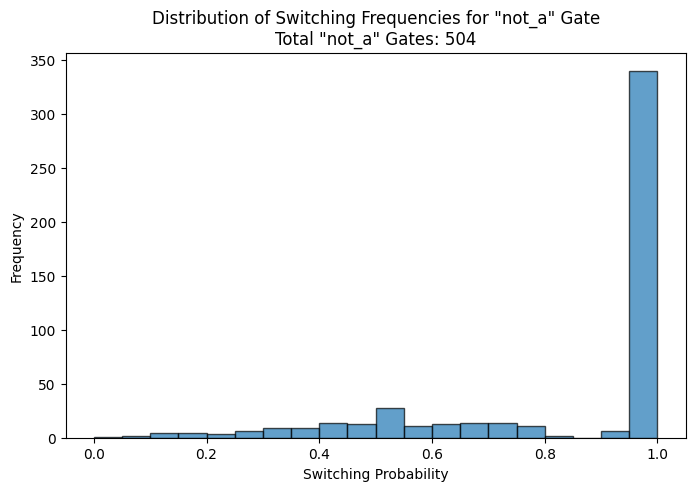

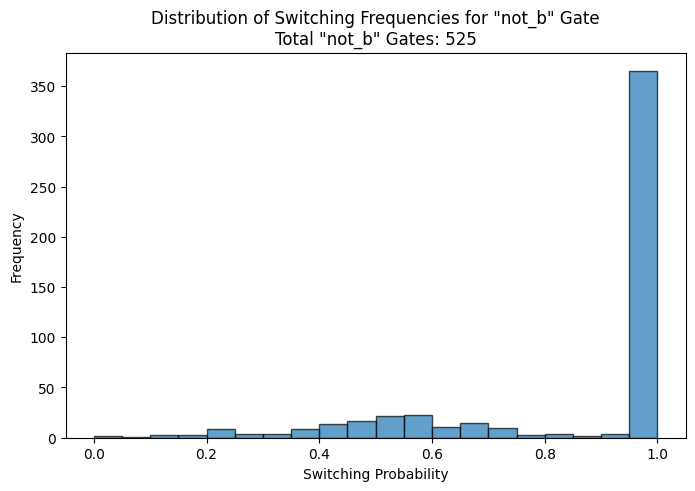

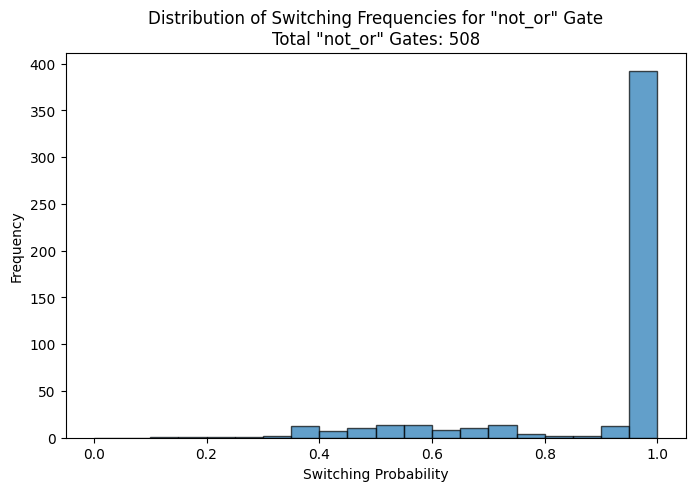

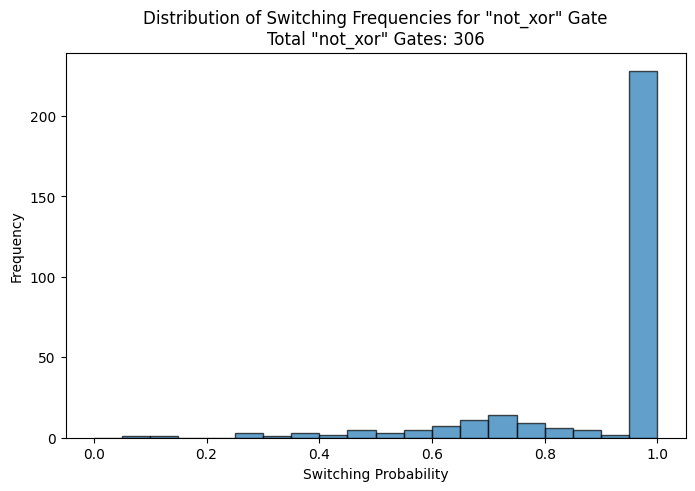

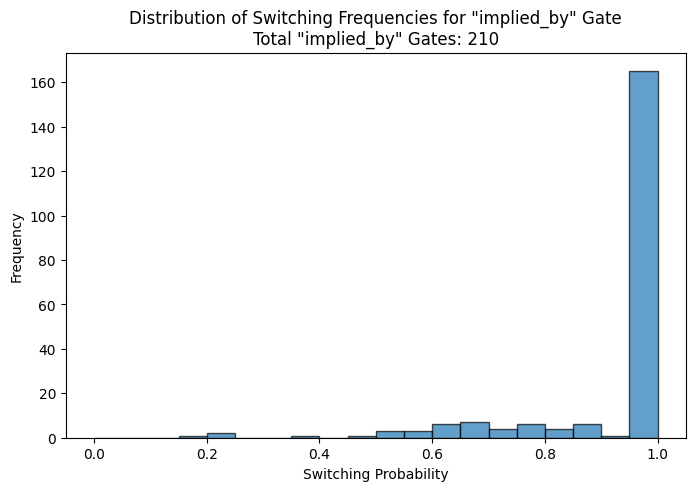

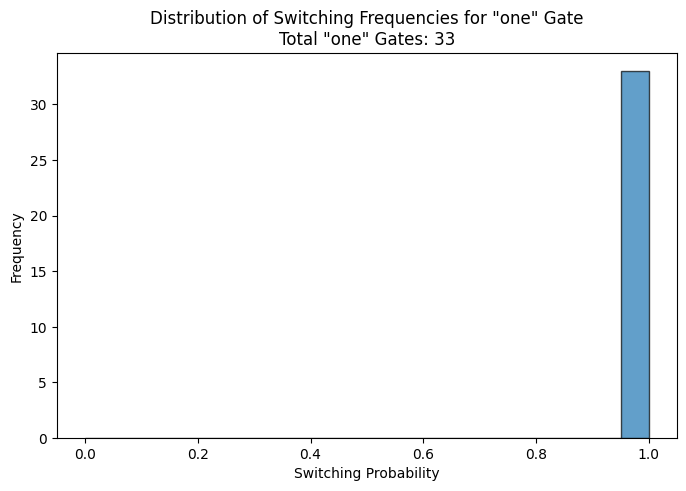

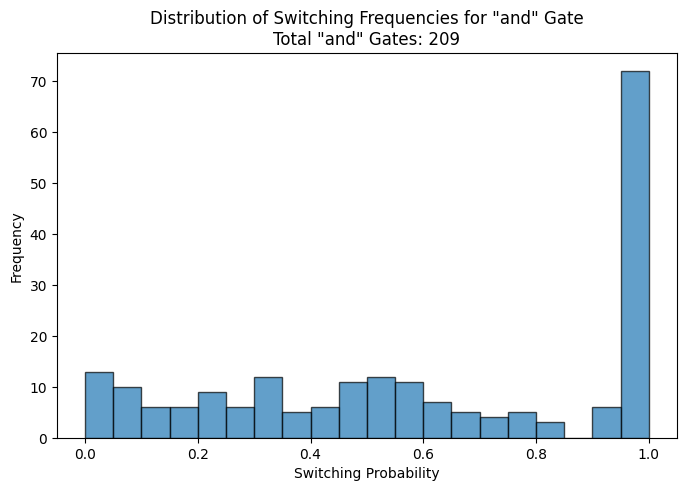

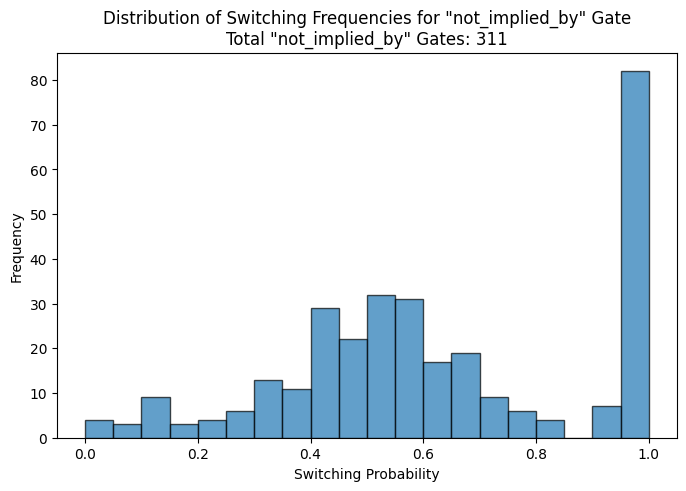

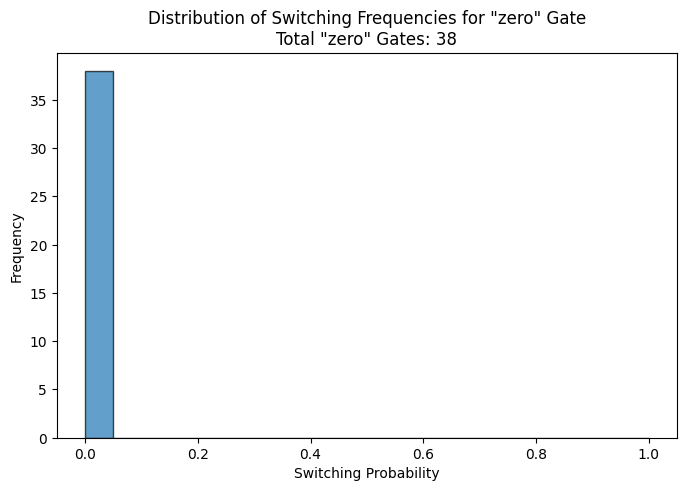

Total "or" Gates: 397
Total "b" Gates: 494
Total "xor" Gates: 305
Total "not_implies" Gates: 331
Total "not_and" Gates: 121
Total "implies" Gates: 206
Total "a" Gates: 502
Total "not_a" Gates: 504
Total "not_b" Gates: 525
Total "not_or" Gates: 508
Total "not_xor" Gates: 306
Total "implied_by" Gates: 210
Total "one" Gates: 33
Total "and" Gates: 209
Total "not_implied_by" Gates: 311
Total "zero" Gates: 38


In [54]:
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_switching_probabilities_by_gate(gate_prob_dict_per_layer):
    """
    Plots the distribution of switching probabilities for each learned gate across layers using histograms.
    
    Args:
        gate_prob_dict_per_layer: A list of dictionaries per layer, each containing the learned gate and its switching probability for neurons in that layer.
    """
    # Dictionary to hold switching probabilities grouped by gate type
    gate_switching_probs = defaultdict(list)
    
    # Dictionary to track the total count of each gate type
    gate_counts = defaultdict(int)

    # Collect switching probabilities and count gates for each gate type across layers
    for layer_dict in gate_prob_dict_per_layer:
        for gate_key, gate_data in layer_dict.items():
            gate_type = gate_data['Learned Gate']  # The gate type (e.g., AND, OR, etc.)
            switching_prob = gate_data['Observed Switching Probability']  # The switching probability for this neuron

            # Append the switching probability to the corresponding gate type
            gate_switching_probs[gate_type].append(switching_prob)
            gate_counts[gate_type] += 1  # Increment the gate count for this gate type

    # Plot the distribution of switching probabilities for each gate type
    for gate_type, probs in gate_switching_probs.items():
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Distribution of Switching Frequencies for \"{gate_type}\" Gate\nTotal \"{gate_type}\" Gates: {gate_counts[gate_type]}")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

    # Print out the total gate counts for each gate type
    for gate_type, count in gate_counts.items():
        print(f"Total \"{gate_type}\" Gates: {count}")

# Example usage with the output of your get_gate_switching_probs function
visualize_switching_probabilities_by_gate(gate_switching_probs)

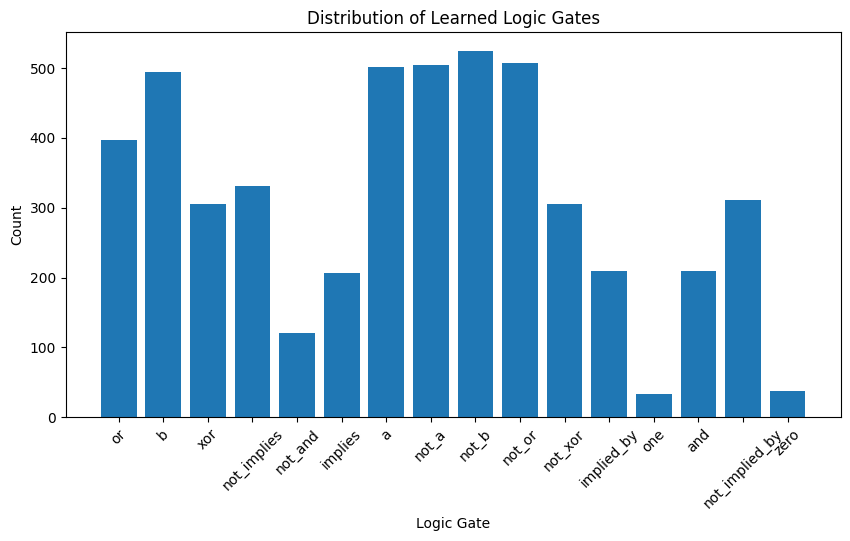

In [55]:
def get_high_activity_neurons(gate_switching_probs, threshold=0.5):
    """
    Finds neurons with switching probability greater than a threshold, and their associated logic gates.
    
    Args:
        gate_switching_probs: Output from get_gate_switching_probs.
        threshold: Switching probability threshold to consider a neuron as high-activity.

    Returns:
        high_activity_neurons: A dictionary with layer, neuron index, learned gate, inputs, and switching probability.
    """
    high_activity_neurons = []

    for layer_idx, gates in enumerate(gate_switching_probs):
        for neuron_idx, gate_info in gates.items():
            if gate_info["Observed Switching Probability"] >= threshold:
                high_activity_neurons.append({
                    "Layer": layer_idx + 1,
                    "Neuron": neuron_idx,
                    "Gate": gate_info["Learned Gate"],
                    "Inputs": gate_info["Inputs"],
                    "Switching Probability": gate_info["Observed Switching Probability"]
                })
    
    return high_activity_neurons

high_activity_neurons = get_high_activity_neurons(gate_switching_probs, threshold=0)
# print(high_activity_neurons)

from collections import Counter

def visualize_gate_distribution(high_activity_neurons):
    """
    Plots a bar chart showing the distribution of learned logic gates for high-activity neurons.
    
    Args:
        high_activity_neurons: Output from get_high_activity_neurons.
    """
    # Count gate occurrences
    gate_counter = Counter([neuron["Gate"] for neuron in high_activity_neurons])
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(gate_counter.keys(), gate_counter.values())
    plt.title("Distribution of Learned Logic Gates")
    plt.xlabel("Logic Gate")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Example usage:
visualize_gate_distribution(high_activity_neurons)